# 🧠 Notebook 03.1 — Custom CNN  ⭐ BEST MODEL
**Results (Test Set):** Accuracy = 0.9780 | F1 = 0.9780 | ROC-AUC = **0.9995**  
**Parameters:** ~200K — lightest model, highest ROC-AUC → **selected for real-time deployment**  
**Normalisation:** `[0.5, 0.5, 0.5]` (trained from scratch — no ImageNet stats)  
**Saved as:** `cnn_cheating_model.pth` → used directly by Notebook 05 (YOLO pipeline)

In [ ]:
import os, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
from google.colab import drive, files

drive.mount('/content/drive')
# ╔══════════════════════════════════════════════════════════╗
# ║          PROJECT-WIDE CONSTANTS — do not change          ║
# ║  These must be identical across all notebooks & scripts  ║
# ╚══════════════════════════════════════════════════════════╝
DATASET_PATH   = '/content/drive/MyDrive/dataset_final'   # split dataset
FRAMES_PATH    = '/content/drive/MyDrive/dataset_frames'  # raw frames
CLASS_NAMES    = ['cheating', 'not_cheating']             # alphabetical (ImageFolder order)
IMG_SIZE       = (224, 224)
BATCH_SIZE     = 32
NUM_EPOCHS     = 20
PATIENCE       = 5

# ── Best model (chosen from Notebook 04 results) ─────────────
# Custom CNN: Acc=0.9780, F1=0.9780, ROC-AUC=0.9995, Params=~200K
# Lightest AND best ROC-AUC → perfect for real-time inference
BEST_MODEL_NAME = 'Custom CNN'
BEST_MODEL_FILE = 'cnn_cheating_model.pth'
BEST_MODEL_KEY  = 'cnn'

# Normalisation for Custom CNN (trained from scratch — NOT ImageNet)
CLF_MEAN = [0.5, 0.5, 0.5]
CLF_STD  = [0.5, 0.5, 0.5]

# All model .pth filenames (for reference / comparison notebook)
MODEL_FILES = {
    'cnn':          'cnn_cheating_model.pth',
    'resnet18':     'resnet18_cheating_model.pth',
    'efficientnet': 'efficientnet_cheating.pth',
    'vit':          'Vision_Transformer.pth',
    'mobilenet':    'mobilenetv2_model.pth',
}


Mounted at /content/drive


In [ ]:
MEAN = [0.5, 0.5, 0.5]
STD  = [0.5, 0.5, 0.5]

train_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])
eval_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

train_data = datasets.ImageFolder(f"{DATASET_PATH}/train", transform=train_tf)
val_data   = datasets.ImageFolder(f"{DATASET_PATH}/val",   transform=eval_tf)
test_data  = datasets.ImageFolder(f"{DATASET_PATH}/test",  transform=eval_tf)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
print(f"Train  : {len(train_data)}  Val: {len(val_data)}  Test: {len(test_data)}")
print(f"Classes: {train_data.classes}")

def unnorm(t, mean, std):
    t = t.clone()
    for c, m, s in zip(range(3), mean, std): t[c] = t[c]*s + m
    return t.clamp(0,1)


Device : cpu
Train  : 1450  Val: 182  Test: 182
Classes: ['cheating', 'not_cheating']


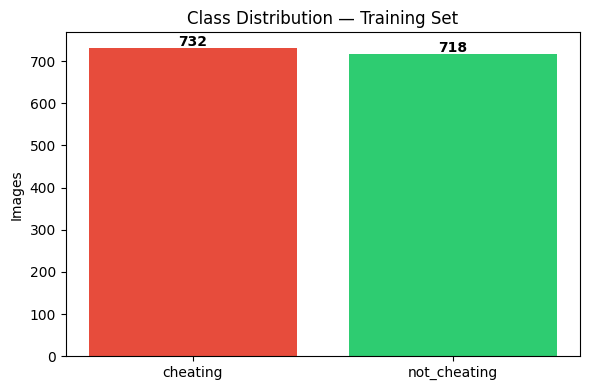

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


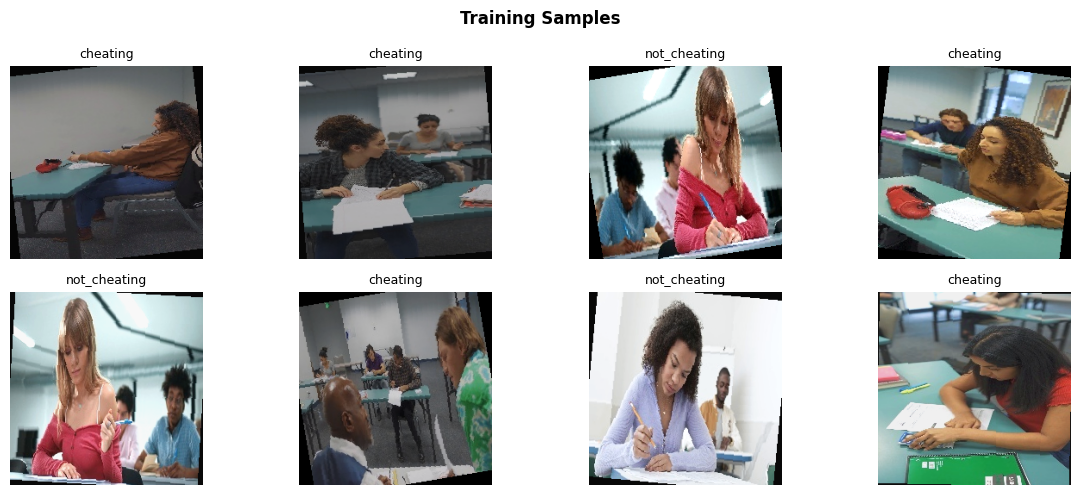

In [ ]:
# Class distribution
counts = [len(os.listdir(f"{DATASET_PATH}/train/{c}")) for c in CLASS_NAMES]
plt.figure(figsize=(6,4))
bars = plt.bar(CLASS_NAMES, counts, color=["#E74C3C","#2ECC71"])
for bar,c in zip(bars,counts): plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3, str(c), ha="center", fontweight="bold")
plt.title("Class Distribution — Training Set"); plt.ylabel("Images"); plt.tight_layout(); plt.show()

# Sample images
imgs, lbls = next(iter(train_loader))
plt.figure(figsize=(12,5))
for i in range(8):
    plt.subplot(2,4,i+1); plt.imshow(unnorm(imgs[i],MEAN,STD).permute(1,2,0)); plt.title(CLASS_NAMES[lbls[i]],fontsize=9); plt.axis("off")
plt.suptitle("Training Samples", fontweight="bold"); plt.tight_layout(); plt.show()


In [ ]:
class CustomCNN(nn.Module):
    """3-block CNN — Best model: Acc=0.9780, ROC-AUC=0.9995, Params=~200K"""
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),  nn.BatchNorm2d(32),  nn.ReLU(inplace=True), nn.MaxPool2d(2,2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True), nn.MaxPool2d(2,2),
            nn.Conv2d(64,128,3,padding=1),nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2,2),
        )
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128,64), nn.BatchNorm1d(64),
            nn.ReLU(inplace=True), nn.Dropout(0.3), nn.Linear(64,num_classes),
        )
    def forward(self,x): return self.classifier(self.pool(self.features(x)))

MODEL_NAME = "Custom CNN"
MODEL_SAVE = BEST_MODEL_FILE   # = cnn_cheating_model.pth

model = CustomCNN().to(device)
total=sum(p.numel() for p in model.parameters())
print(f"✅ Custom CNN | Params: {total:,}")
print(model)


✅ Custom CNN | Params: 102,210
CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(star

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

In [ ]:
train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_acc, best_wts, patience_count = 0.0, copy.deepcopy(model.state_dict()), 0

for epoch in range(NUM_EPOCHS):
    model.train()
    rl=rc=rt=0
    for imgs,lbls in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]", leave=False):
        imgs,lbls = imgs.to(device),lbls.to(device)
        optimizer.zero_grad(); out=model(imgs); loss=criterion(out,lbls); loss.backward(); optimizer.step()
        rl+=loss.item(); _,p=torch.max(out,1); rc+=(p==lbls).sum().item(); rt+=lbls.size(0)
    tl,ta = rl/len(train_loader), rc/rt

    model.eval(); vl=vc=vt=0
    with torch.no_grad():
        for imgs,lbls in val_loader:
            imgs,lbls=imgs.to(device),lbls.to(device); out=model(imgs); loss=criterion(out,lbls)
            vl+=loss.item(); _,p=torch.max(out,1); vc+=(p==lbls).sum().item(); vt+=lbls.size(0)
    vla,va = vl/len(val_loader), vc/vt

    train_losses.append(tl); val_losses.append(vla); train_accs.append(ta); val_accs.append(va)
    scheduler.step(va)

    if va > best_val_acc:
        best_val_acc,best_wts,patience_count = va,copy.deepcopy(model.state_dict()),0; status="✅ best"
    else:
        patience_count+=1; status=f"⚠ ({patience_count}/{PATIENCE})"

    print(f"Epoch {epoch+1:>2}/{NUM_EPOCHS} | Train loss {tl:.4f} acc {ta:.4f} | Val loss {vla:.4f} acc {va:.4f} | {status}")
    if patience_count >= PATIENCE: print("🛑 Early stopping."); break

model.load_state_dict(best_wts)
print(f"\n🏆 Best val acc: {best_val_acc:.4f}")


Epoch  1/20 | Train loss 0.4209 acc 0.8276 | Val loss 0.2953 acc 0.9231 | ✅ best


Epoch  2/20 | Train loss 0.2909 acc 0.8952 | Val loss 0.2762 acc 0.9396 | ✅ best


Epoch  3/20 | Train loss 0.2617 acc 0.8910 | Val loss 0.3047 acc 0.8626 | ⚠ (1/5)


Epoch  4/20 | Train loss 0.2201 acc 0.9207 | Val loss 0.5481 acc 0.7527 | ⚠ (2/5)


Epoch  5/20 | Train loss 0.2021 acc 0.9269 | Val loss 0.1518 acc 0.9451 | ✅ best


...

Epoch 16/20 | Train loss 0.0706 acc 0.9779 | Val loss 0.0370 acc 0.9945 | ✅ best


Epoch 17/20 | Train loss 0.0729 acc 0.9759 | Val loss 0.0439 acc 0.9945 | ⚠ (1/5)


Epoch 18/20 | Train loss 0.0949 acc 0.9690 | Val loss 0.0319 acc 0.9890 | ⚠ (2/5)


Epoch 19/20 | Train loss 0.0870 acc 0.9676 | Val loss 0.0325 acc 0.9890 | ⚠ (3/5)


Epoch 20/20 | Train loss 0.0636 acc 0.9766 | Val loss 0.0555 acc 0.9835 | ⚠ (4/5)

🏆 Best val acc: 0.9945


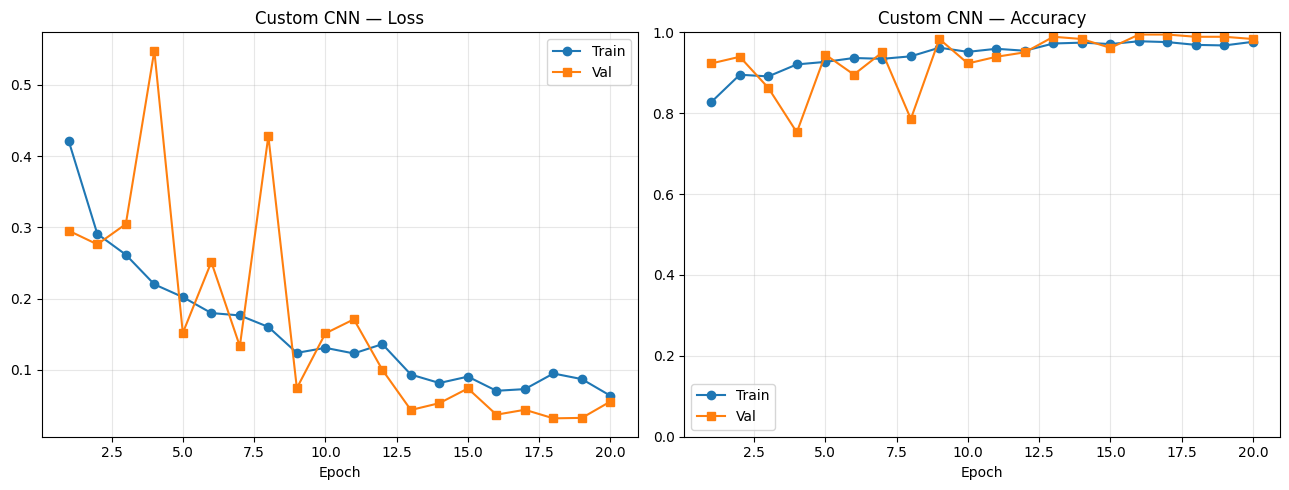

Train Acc: 0.9766 | Val Acc: 0.9835 | Gap: 0.0070


In [ ]:
epochs_r=range(1,len(train_losses)+1)
fig,ax=plt.subplots(1,2,figsize=(13,5))
ax[0].plot(epochs_r,train_losses,"o-",label="Train"); ax[0].plot(epochs_r,val_losses,"s-",label="Val")
ax[0].set_title(f"{MODEL_NAME} — Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(epochs_r,train_accs,"o-",label="Train"); ax[1].plot(epochs_r,val_accs,"s-",label="Val")
ax[1].set_title(f"{MODEL_NAME} — Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].set_ylim(0,1); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
gap=abs(train_accs[-1]-val_accs[-1])
print(f"Train Acc: {train_accs[-1]:.4f} | Val Acc: {val_accs[-1]:.4f} | Gap: {gap:.4f}")


  Test Accuracy: 0.9780
              precision    recall  f1-score   support

    cheating       1.00      0.96      0.98        92
not_cheating       0.96      1.00      0.98        90

    accuracy                           0.98       182
   macro avg       0.98      0.98      0.98       182
weighted avg       0.98      0.98      0.98       182



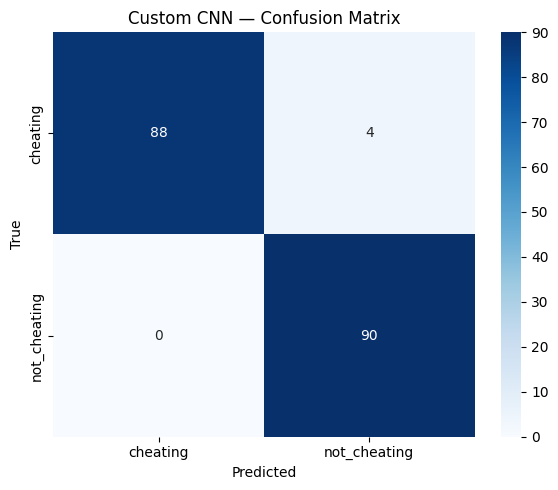

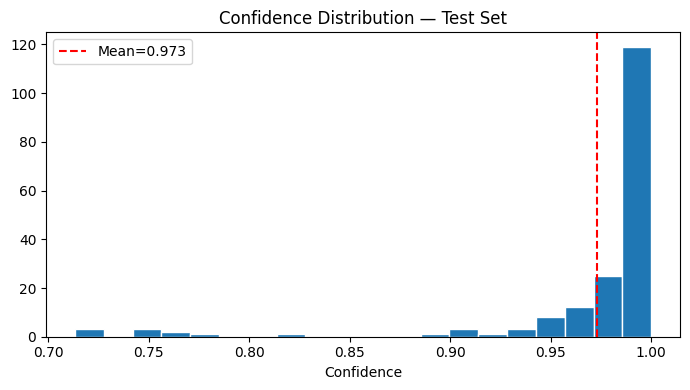

In [ ]:
def run_eval(model, loader):
    model.eval(); ap,al,ab=[],[],[]
    with torch.no_grad():
        for imgs,lbls in loader:
            out=model(imgs.to(device)); prob=F.softmax(out,dim=1); _,p=torch.max(out,1)
            ap.extend(p.cpu().numpy()); al.extend(lbls.numpy()); ab.extend(prob.cpu().numpy())
    return np.array(ap),np.array(al),np.array(ab)

tp,tl,tb = run_eval(model, test_loader)
print("="*55); print(f"  Test Accuracy: {(tp==tl).mean():.4f}"); print("="*55)
print(classification_report(tl, tp, target_names=CLASS_NAMES))

# Confusion matrix
cm=confusion_matrix(tl,tp)
plt.figure(figsize=(6,5)); sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES)
plt.title(f"{MODEL_NAME} — Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()

# Confidence distribution
confs=tb.max(axis=1)
plt.figure(figsize=(7,4)); plt.hist(confs,bins=20,edgecolor="white")
plt.axvline(confs.mean(),color="red",linestyle="--",label=f"Mean={confs.mean():.3f}")
plt.title("Confidence Distribution — Test Set"); plt.xlabel("Confidence"); plt.legend(); plt.tight_layout(); plt.show()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Wrong predictions: 4/182


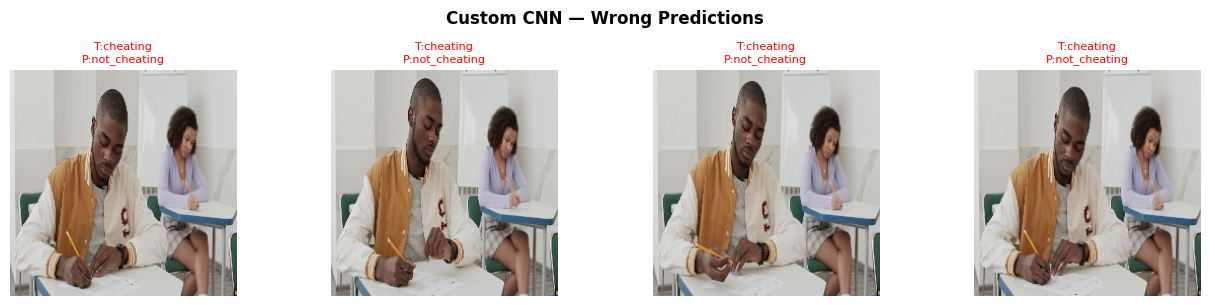

In [ ]:
wi,wp,wt=[],[],[]
model.eval()
with torch.no_grad():
    for imgs,lbls in test_loader:
        out=model(imgs.to(device)); _,preds=torch.max(out,1)
        for i in range(len(lbls)):
            if preds[i].cpu()!=lbls[i]: wi.append(imgs[i]); wp.append(preds[i].cpu().item()); wt.append(lbls[i].item())
print(f"Wrong predictions: {len(wi)}/{len(test_data)}")
if wi:
    n=min(12,len(wi)); plt.figure(figsize=(13,8))
    for i in range(n):
        plt.subplot(3,4,i+1); plt.imshow(unnorm(wi[i],MEAN,STD).permute(1,2,0).clamp(0,1)); plt.axis("off")
        plt.title(f"T:{CLASS_NAMES[wt[i]]}\nP:{CLASS_NAMES[wp[i]]}",color="red",fontsize=8)
    plt.suptitle(f"{MODEL_NAME} — Wrong Predictions",fontweight="bold"); plt.tight_layout(); plt.show()


Train: 0.9648
Val: 0.9945
Test: 0.9780


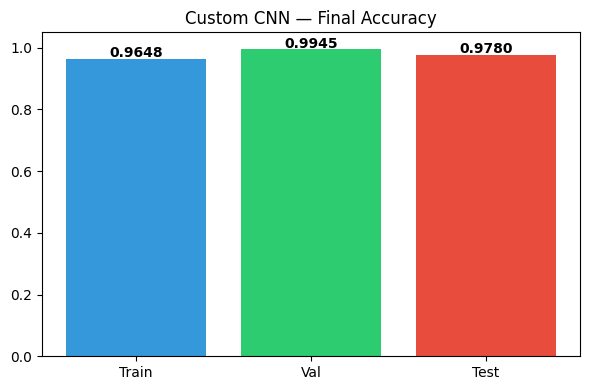

In [ ]:
def split_acc(loader):
    model.eval(); c=t=0
    with torch.no_grad():
        for imgs,lbls in loader:
            imgs,lbls=imgs.to(device),lbls.to(device); _,p=torch.max(model(imgs),1)
            c+=(p==lbls).sum().item(); t+=lbls.size(0)
    return c/t
tr_a=split_acc(train_loader); vl_a=split_acc(val_loader); te_a=split_acc(test_loader)
for n,v in [("Train",tr_a),("Val",vl_a),("Test",te_a)]: print(f"{n}: {v:.4f}")
plt.figure(figsize=(6,4))
bars=plt.bar(["Train","Val","Test"],[tr_a,vl_a,te_a],color=["#3498DB","#2ECC71","#E74C3C"])
for bar,v in zip(bars,[tr_a,vl_a,te_a]): plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.005,f"{v:.4f}",ha="center",fontweight="bold")
plt.ylim(0,1.05); plt.title(f"{MODEL_NAME} — Final Accuracy"); plt.tight_layout(); plt.show()


In [ ]:
ext_tf = transforms.Compose([transforms.Resize(IMG_SIZE),transforms.ToTensor(),transforms.Normalize(mean=MEAN,std=STD)])
def predict_external():
    uploaded=files.upload()
    for fn in uploaded:
        img=Image.open(fn).convert("RGB"); t=ext_tf(img).unsqueeze(0).to(device)
        model.eval()
        with torch.no_grad(): probs=F.softmax(model(t),dim=1).cpu().numpy()[0]
        pred=probs.argmax()
        fig,ax=plt.subplots(1,2,figsize=(10,4))
        ax[0].imshow(img); ax[0].axis("off"); ax[0].set_title("Input")
        b=ax[1].bar(CLASS_NAMES,probs,color=["#E74C3C","#2ECC71"]); ax[1].set_ylim(0,1)
        for bar,p in zip(b,probs): ax[1].text(bar.get_x()+bar.get_width()/2,p+0.02,f"{p:.2f}",ha="center",fontweight="bold")
        ax[1].set_title(f"Prediction: {CLASS_NAMES[pred]} ({probs[pred]:.2%})")
        plt.tight_layout(); plt.show()
predict_external()


NameError: name 'transforms' is not defined

In [ ]:
torch.save(model.state_dict(), MODEL_SAVE)
print(f"💾 Saved → {MODEL_SAVE}")
files.download(MODEL_SAVE)
# Also save to Drive for easy access in the YOLO pipeline
import shutil
drive_models = "/content/drive/MyDrive/saved_models"
os.makedirs(drive_models, exist_ok=True)
shutil.copy(MODEL_SAVE, os.path.join(drive_models, MODEL_SAVE))
print(f"💾 Also saved to Drive: {drive_models}/{MODEL_SAVE}")


💾 Saved → cnn_cheating_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

💾 Also saved to Drive: /content/drive/MyDrive/saved_models/cnn_cheating_model.pth
